In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [39]:
# importing the dataset
EPL24_25=pd.read_csv("C:/Users/LENOVO/Downloads/fbref_PL_2024-25.csv")
display(EPL24_25)

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,...,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
0,1,Max Aarons,eng ENG,DF,Bournemouth,24.0,2000.0,3,1,86,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2,Joshua Acheampong,eng ENG,DF,Chelsea,18.0,2006.0,4,2,170,...,0.00,0.00,0.00,0.00,0.00,0.12,0.00,0.12,0.12,0.12
2,3,Tyler Adams,us USA,MF,Bournemouth,25.0,1999.0,28,21,1965,...,0.00,0.14,0.14,0.00,0.14,0.07,0.05,0.12,0.07,0.12
3,4,Tosin Adarabioyo,eng ENG,DF,Chelsea,26.0,1997.0,22,15,1409,...,0.06,0.06,0.13,0.06,0.13,0.06,0.01,0.07,0.06,0.07
4,5,Simon Adingra,ci CIV,"FW,MF",Brighton,22.0,2002.0,29,12,1097,...,0.16,0.16,0.33,0.16,0.33,0.20,0.20,0.40,0.20,0.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,570,Ashley Young,eng ENG,DF,Everton,39.0,1985.0,32,19,1875,...,0.05,0.14,0.19,0.05,0.19,0.01,0.11,0.12,0.01,0.12
570,571,Illia Zabarnyi,ua UKR,DF,Bournemouth,21.0,2002.0,36,35,3109,...,0.00,0.03,0.03,0.00,0.03,0.04,0.02,0.06,0.04,0.06
571,572,Oleksandr Zinchenko,ua UKR,"DF,MF",Arsenal,27.0,1996.0,15,5,527,...,0.00,0.17,0.17,0.00,0.17,0.11,0.03,0.14,0.11,0.14
572,573,Joshua Zirkzee,nl NED,"FW,MF",Manchester Utd,23.0,2001.0,32,14,1402,...,0.19,0.06,0.26,0.19,0.26,0.31,0.10,0.41,0.31,0.41


In [40]:
# cleaning the dataset
EPL24_25=EPL24_25.sort_values('Min',ascending=False).drop_duplicates(subset='Player',keep='first').reset_index(drop=True)
EPL24_25=EPL24_25[EPL24_25['Min']>900].reset_index(drop=True)
EPL24_25['Position']=EPL24_25['Pos'].str.split(',').str[0]
forwards=EPL24_25[EPL24_25['Position']=='FW'].copy().reset_index(drop=True)
display(forwards)
print(forwards.columns.tolist())

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,...,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90,Position
0,341,Bryan Mbeumo,cm CMR,FW,Brentford,24.0,1999.0,38,38,3414,...,0.18,0.71,0.40,0.58,0.32,0.22,0.54,0.20,0.42,FW
1,450,Mohamed Salah,eg EGY,FW,Liverpool,32.0,1992.0,38,38,3371,...,0.48,1.25,0.53,1.01,0.67,0.38,1.05,0.49,0.87,FW
2,467,Antoine Semenyo,gh GHA,FW,Bournemouth,24.0,2000.0,37,36,3203,...,0.14,0.45,0.31,0.45,0.28,0.16,0.44,0.28,0.44,FW
3,445,Morgan Rogers,eng ENG,"FW,MF",Aston Villa,22.0,2002.0,37,37,3114,...,0.29,0.52,0.23,0.52,0.19,0.23,0.42,0.19,0.42,FW
4,254,Alex Iwobi,ng NGA,"FW,MF",Fulham,28.0,1996.0,38,35,2981,...,0.18,0.45,0.27,0.45,0.14,0.21,0.36,0.14,0.36,FW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,370,Rodrigo Muniz,br BRA,FW,Fulham,23.0,2001.0,31,8,964,...,0.09,0.84,0.75,0.84,0.54,0.07,0.61,0.54,0.61,FW
73,72,David Brooks,wls WAL,"FW,MF",Bournemouth,27.0,1997.0,29,9,960,...,0.00,0.19,0.19,0.19,0.24,0.18,0.41,0.24,0.41,FW
74,78,Wes Burns,wls WAL,"FW,DF",Ipswich Town,29.0,1994.0,18,12,926,...,0.10,0.10,0.00,0.10,0.05,0.16,0.21,0.05,0.21,FW
75,384,Christopher Nkunku,fr FRA,FW,Chelsea,26.0,1997.0,27,9,921,...,0.20,0.49,0.29,0.49,0.47,0.21,0.68,0.47,0.67,FW


['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'xG', 'npxG', 'xAG', 'npxG+xAG', 'PrgC', 'PrgP', 'PrgR', 'Gls_90', 'Ast_90', 'G+A_90', 'G-PK_90', 'G+A-PK_90', 'xG_90', 'xAG_90', 'xG+xAG_90', 'npxG_90', 'npxG+xAG_90', 'Position']


In [41]:
# calculating values
forwards['xG_diff_90']=forwards['Gls_90']-forwards['xG_90']
forwards_sorted=forwards.sort_values('xG_diff_90',ascending=False).reset_index(drop=True)

# Top 5 most clinical and most wasteful
print("Top 5 Most Clinical:")
print(forwards_sorted[['Player', 'Squad', 'Gls_90', 'xG_90', 'xG_diff_90']].head(5))

print("\nTop 5 Most Wasteful:")
print(forwards_sorted[['Player', 'Squad', 'Gls_90', 'xG_90', 'xG_diff_90']].tail(5))


Top 5 Most Clinical:
            Player            Squad  Gls_90  xG_90  xG_diff_90
0     Bryan Mbeumo        Brentford    0.53   0.32        0.21
1  Marcus Rashford   Manchester Utd    0.37   0.16        0.21
2    Rodrigo Muniz           Fulham    0.75   0.54        0.21
3       Chris Wood  Nott'ham Forest    0.61   0.41        0.20
4       Cody Gakpo        Liverpool    0.47   0.33        0.14

Top 5 Most Wasteful:
                   Player            Squad  Gls_90  xG_90  xG_diff_90
72     Christopher Nkunku          Chelsea    0.29   0.47       -0.18
73  Dominic Calvert-Lewin          Everton    0.17   0.38       -0.21
74                  Sávio  Manchester City    0.05   0.26       -0.21
75         Cameron Archer      Southampton    0.12   0.36       -0.24
76          Eddie Nketiah   Crystal Palace    0.26   0.50       -0.24


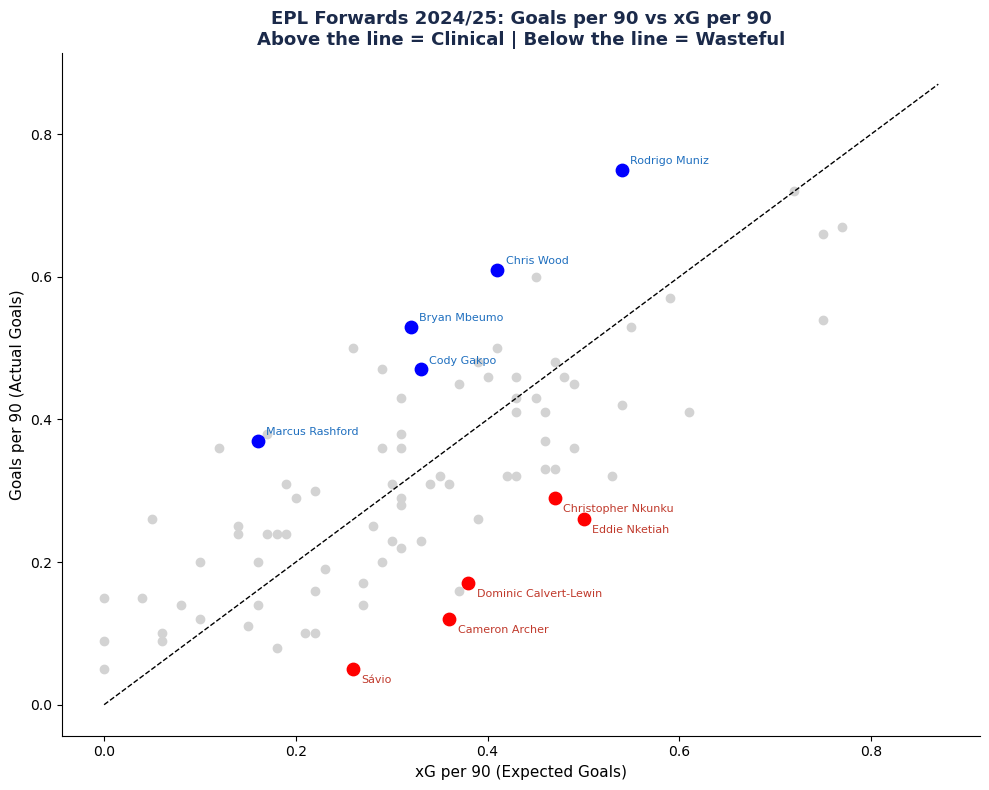

In [49]:
# the chart
fig,ax=plt.subplots(figsize=(10,8))
ax.scatter(forwards['Gls_90'],forwards['xG_90'],color='lightgrey',zorder=2)
max_val=max(forwards['Gls_90'].max(),forwards['xG_90'].max())+0.1
ax.plot([0, max_val], [0, max_val], color='black', linewidth=1, linestyle='--')
top5=forwards_sorted.head(5)
ax.scatter(top5['xG_90'],top5['Gls_90'],color='blue',zorder=3,s=80)
bot5=forwards_sorted.tail(5)
ax.scatter(bot5['xG_90'],bot5['Gls_90'],color='red',zorder=3,s=80)

# chart labelling
for _, row in top5.iterrows():
    ax.annotate(row['Player'], 
                (row['xG_90'], row['Gls_90']),
                textcoords='offset points',
                xytext=(6, 4),
                fontsize=8, color='#1F6FBF')
for _, row in bot5.iterrows():
    ax.annotate(row['Player'],
                (row['xG_90'], row['Gls_90']),
                textcoords='offset points',
                xytext=(6, -10),
                fontsize=8, color='#C0392B')

ax.set_xlabel('xG per 90 (Expected Goals)', fontsize=11)
ax.set_ylabel('Goals per 90 (Actual Goals)', fontsize=11)
ax.set_title('EPL Forwards 2024/25: Goals per 90 vs xG per 90\nAbove the line = Clinical | Below the line = Wasteful',
             fontsize=13, fontweight='bold', color='#1B2A4A')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('C:/Users/LENOVO/Downloads/forwards_xg_scatter.jpg', dpi=150, bbox_inches='tight')
plt.show()